Found 14345 files belonging to 4 classes.
Found 2112 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 3, 3, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,328,356 (85.18 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/10
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 497s 267ms/step - accuracy: 0.7994 - loss: 0.5383 - val_accuracy: 0.8191 - val_loss: 0.5083 - learning_rate: 1.0000e-04
Epoch 2/10
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 481s 268ms/step - accuracy: 0.8602 - loss: 0.3677 - val_accuracy: 0.8248 - val_loss: 0.5071 - learning_rate: 1.0000e-04
Epoch 3/10
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 465s 259ms/step - accuracy: 0.8791 - loss: 0.3180 - val_accuracy: 0.8655 - val_loss: 0.4147 - learning_rate: 1.0000e-04
Epoch 4/10
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 505s 261ms/step - accuracy: 0.8935 - loss: 0.2827 - val_accuracy: 0.8679 - val_loss: 0.3860 - learning_rate: 1.0000e-04
Epoch 5/10
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 425s 237ms/step - accuracy: 0.8993 - loss: 0.2657 - val_accuracy: 0.8717 - val_loss: 0.3846 - learning_rate: 1.0000e-04
Epoch 6/10
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 447s 240ms/step - accuracy: 0.9067 - loss: 0.2419 - val_accuracy: 0.8774 - val_loss: 0.3722 - learning_rate: 1.0000e-04
Epoch 7/10
1794/1794 ━━━━━━━

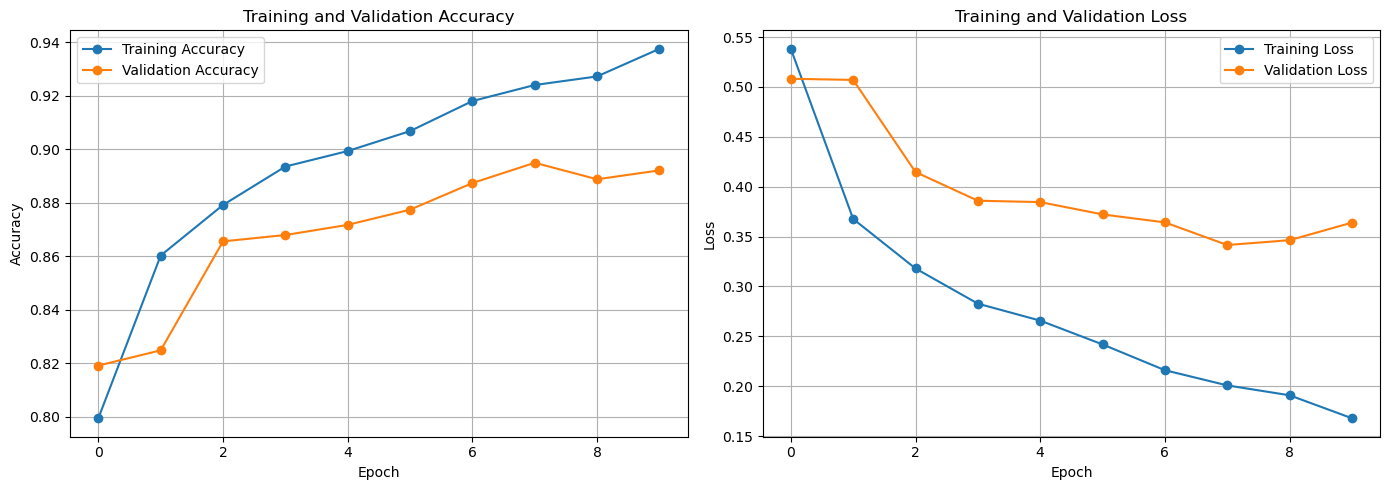

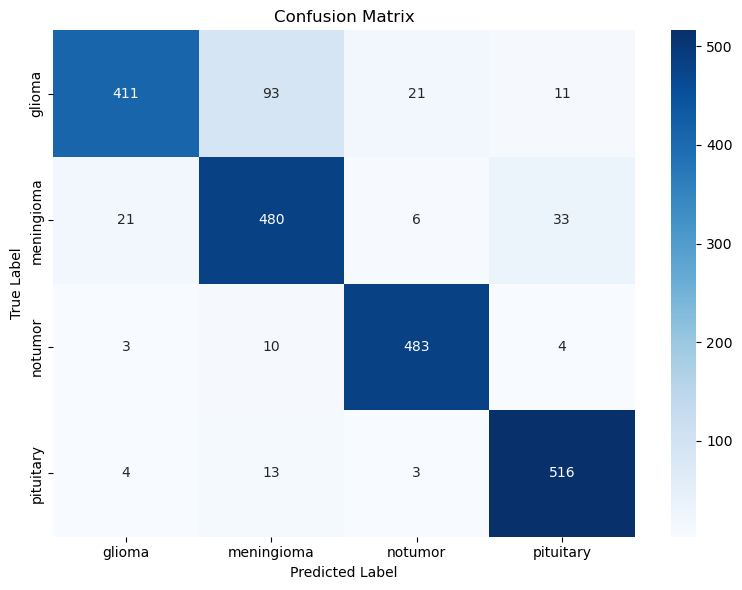


Classification Report:

              precision    recall  f1-score   support

      glioma     0.9362    0.7668    0.8431       536
  meningioma     0.8054    0.8889    0.8451       540
     notumor     0.9415    0.9660    0.9536       500
   pituitary     0.9149    0.9627    0.9382       536

    accuracy                         0.8949      2112
   macro avg     0.8995    0.8961    0.8950      2112
weighted avg     0.8986    0.8949    0.8939      2112



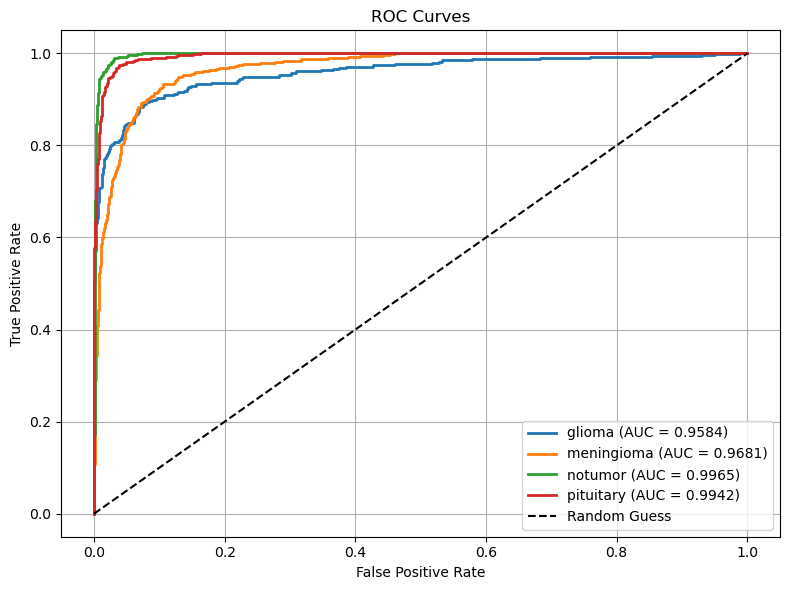

In [3]:
# ============================================================
# FAST CPU-FRIENDLY InceptionV3 TRAINING
# Jupyter Notebook / Google Colab
#
# Optimized for CPU:
# - Image size: 150x150 (smaller than 299x299)
# - Batch size: 8
# - Epochs: 10
# - Frozen InceptionV3 (no fine-tuning)
# - cache() + prefetch()
#
# Outputs:
# - Accuracy/Loss Graphs
# - Confusion Matrix
# - Classification Report
# - ROC Curves
# ============================================================

# Uncomment if packages are missing
# import sys
# !{sys.executable} -m pip install tensorflow matplotlib seaborn scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

# ============================================================
# 1. DATASET PATH
# ============================================================
# Windows Jupyter Notebook
DATASET_DIR = r"C:\Users\yadav\Downloads\BrainTumorProject\final_merged_dataset"

# Google Colab
# DATASET_DIR = "/content/drive/MyDrive/BrainTumorProject/final_merged_dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR = os.path.join(DATASET_DIR, "Testing")

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Training folder not found: {TRAIN_DIR}")

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Testing folder not found: {TEST_DIR}")

# ============================================================
# 2. CONFIGURATION
# ============================================================
IMG_SIZE = (150, 150)   # Smaller image size for faster CPU training
BATCH_SIZE = 8
EPOCHS = 10
SEED = 42

MODEL_DIR = "inceptionv3_cpu_output"
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# 3. LOAD DATASET
# ============================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# ============================================================
# 4. SPEED OPTIMIZATION
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

train_ds = train_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# ============================================================
# 5. BUILD InceptionV3 MODEL
# ============================================================
base_model = InceptionV3(
    input_shape=(150, 150, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

inputs = layers.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# 6. CALLBACKS
# ============================================================
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

# ============================================================
# 7. TRAIN MODEL
# ============================================================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ============================================================
# 8. EVALUATE MODEL
# ============================================================
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ============================================================
# 9. SAVE MODEL
# ============================================================
model.save(os.path.join(MODEL_DIR, "inceptionv3_cpu.keras"))
print("Model saved successfully.")

# ============================================================
# 10. TRAINING & VALIDATION GRAPHS
# ============================================================
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], marker="o",
         label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o",
         label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], marker="o",
         label="Training Loss")
plt.plot(history.history["val_loss"], marker="o",
         label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 11. PREDICTIONS
# ============================================================
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_true.extend(true)
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ============================================================
# 12. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# ============================================================
# 14. ROC CURVES
# ============================================================
y_true_bin = label_binarize(
    y_true,
    classes=list(range(num_classes))
)

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()